In [1]:
# =====================================================
# Imports
# =====================================================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# =====================================================
# Dataset Path
# =====================================================
dataset_dir = "/kaggle/input/datasets/shashwatwork/fruitnet-indian-fruits-dataset-with-quality/Processed Images_Fruits"

target_size = (128, 128)

X = []
y_quality = []
y_fruit = []

cv2.setNumThreads(4)


# =====================================================
# Load Images
# =====================================================
for quality in os.listdir(dataset_dir):

    quality_path = os.path.join(dataset_dir, quality)

    if not os.path.isdir(quality_path):
        continue

    for fruit in os.listdir(quality_path):

        fruit_path = os.path.join(quality_path, fruit)

        if not os.path.isdir(fruit_path):
            continue

        images = [
            f for f in os.listdir(fruit_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        for img_file in images:

            img_path = os.path.join(fruit_path, img_file)

            img = cv2.imread(img_path)

            if img is None:
                continue

            # BGR → RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Resize
            img = cv2.resize(img, target_size)

            # Normalize
            img = img / 255.0

            X.append(img)
            y_quality.append(quality)
            y_fruit.append(fruit)


# Convert to NumPy arrays
X = np.array(X, dtype=np.float32)
y_quality = np.array(y_quality)
y_fruit = np.array(y_fruit)


# =====================================================
# Dataset Summary
# =====================================================
print("Number of images:", X.shape)

print("\nQuality classes:")
print(np.unique(y_quality))

print("\nFruit classes:")
print(np.unique(y_fruit))

print("\nNumber of quality classes:", len(np.unique(y_quality)))
print("Number of fruit classes:", len(np.unique(y_fruit)))

Number of images: (19526, 128, 128, 3)

Quality classes:
['Bad Quality_Fruits' 'Good Quality_Fruits' 'Mixed Qualit_Fruits']

Fruit classes:
['Apple' 'Apple_Bad' 'Apple_Good' 'Banana' 'Banana_Bad' 'Banana_Good'
 'Guava' 'Guava_Bad' 'Guava_Good' 'Lemon' 'Lime_Bad' 'Lime_Good' 'Orange'
 'Orange_Bad' 'Orange_Good' 'Pomegranate' 'Pomegranate_Bad'
 'Pomegranate_Good']

Number of quality classes: 3
Number of fruit classes: 18


In [3]:
# =====================================================
# Encode Quality Labels
# =====================================================
le_quality = LabelEncoder()

y_quality_num = le_quality.fit_transform(y_quality)
y_quality_onehot = to_categorical(y_quality_num)


# =====================================================
# Encode Fruit Labels
# =====================================================
le_fruit = LabelEncoder()

y_fruit_num = le_fruit.fit_transform(y_fruit)
y_fruit_onehot = to_categorical(y_fruit_num)


# =====================================================
# Summary
# =====================================================
print("Quality classes:", le_quality.classes_)
print("Fruit classes:", le_fruit.classes_)

print("\nX shape:", X.shape)
print("Quality labels shape:", y_quality_onehot.shape)
print("Fruit labels shape:", y_fruit_onehot.shape)

Quality classes: ['Bad Quality_Fruits' 'Good Quality_Fruits' 'Mixed Qualit_Fruits']
Fruit classes: ['Apple' 'Apple_Bad' 'Apple_Good' 'Banana' 'Banana_Bad' 'Banana_Good'
 'Guava' 'Guava_Bad' 'Guava_Good' 'Lemon' 'Lime_Bad' 'Lime_Good' 'Orange'
 'Orange_Bad' 'Orange_Good' 'Pomegranate' 'Pomegranate_Bad'
 'Pomegranate_Good']

X shape: (19526, 128, 128, 3)
Quality labels shape: (19526, 3)
Fruit labels shape: (19526, 18)


In [4]:
# =====================================================
# Train / Validation Split
# =====================================================
X_train, X_val, yq_train, yq_val, yf_train, yf_val = train_test_split(
    X,
    y_quality_onehot,
    y_fruit_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_quality
)


print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 15620
Validation samples: 3906


In [5]:
# =====================================================
# Build Multitask CNN
# =====================================================

input_img = Input(shape=(128, 128, 3))


# Convolution Block 1
x = Conv2D(32, (3, 3), activation='relu')(input_img)
x = MaxPooling2D(2, 2)(x)


# Convolution Block 2
x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D(2, 2)(x)


# Convolution Block 3
x = Conv2D(128, (3, 3), activation='relu')(x)
x = MaxPooling2D(2, 2)(x)


# Fully Connected Layers
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)


# =====================================================
# Quality Output
# =====================================================
quality_output = Dense(
    y_quality_onehot.shape[1],
    activation='softmax',
    name='quality_output'
)(x)


# =====================================================
# Fruit Output
# =====================================================
fruit_output = Dense(
    y_fruit_onehot.shape[1],
    activation='softmax',
    name='fruit_output'
)(x)


# =====================================================
# Create Model
# =====================================================
model = Model(
    inputs=input_img,
    outputs=[quality_output, fruit_output]
)


# =====================================================
# Compile Model
# =====================================================
model.compile(
    optimizer='adam',

    loss={
        'quality_output': 'categorical_crossentropy',
        'fruit_output': 'categorical_crossentropy'
    },

    metrics={
        'quality_output': 'accuracy',
        'fruit_output': 'accuracy'
    }
)


model.summary()

I0000 00:00:1790266099.004159      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790266099.007226      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 63, 63,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 25088)     │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  6,422,784 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quality_output      │ (None, 3)         │        771 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fruit_output        │ (None, 18)        │      4,626 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,521,429 (24.88 MB)

 Trainable params: 6,521,429 (24.88 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# =====================================================
# Early Stopping
# =====================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


# =====================================================
# Train Model
# =====================================================
history = model.fit(
    X_train,
    {
        'quality_output': yq_train,
        'fruit_output': yf_train
    },

    validation_data=(
        X_val,
        {
            'quality_output': yq_val,
            'fruit_output': yf_val
        }
    ),

    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50


2026-09-24 16:08:31.110448: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-24 16:08:31.258094: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  5/489 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - fruit_output_accuracy: 0.0882 - fruit_output_loss: 3.3046 - loss: 4.8707 - quality_output_accuracy: 0.4951 - quality_output_loss: 1.5661   

I0000 00:00:1790266113.726641     133 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


488/489 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - fruit_output_accuracy: 0.4616 - fruit_output_loss: 1.7762 - loss: 2.3767 - quality_output_accuracy: 0.7543 - quality_output_loss: 0.6005

2026-09-24 16:08:43.277895: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-24 16:08:43.420176: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


489/489 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - fruit_output_accuracy: 0.6032 - fruit_output_loss: 1.2748 - loss: 1.6895 - quality_output_accuracy: 0.8372 - quality_output_loss: 0.4132 - val_fruit_output_accuracy: 0.8338 - val_fruit_output_loss: 0.5745 - val_loss: 0.7998 - val_quality_output_accuracy: 0.9173 - val_quality_output_loss: 0.2195
Epoch 2/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - fruit_output_accuracy: 0.8286 - fruit_output_loss: 0.5392 - loss: 0.7339 - quality_output_accuracy: 0.9298 - quality_output_loss: 0.1935 - val_fruit_output_accuracy: 0.8879 - val_fruit_output_loss: 0.3705 - val_loss: 0.5460 - val_quality_output_accuracy: 0.9388 - val_quality_output_loss: 0.1715
Epoch 3/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - fruit_output_accuracy: 0.8823 - fruit_output_loss: 0.3569 - loss: 0.5004 - quality_output_accuracy: 0.9490 - quality_output_loss: 0.1426 - val_fruit_output_accuracy: 0.8799 - val_fruit_output_loss: 0.3463 - val_loss: 0.5172 - val_quality_output_accura

In [7]:
# =====================================================
# Predict on Validation Set
# =====================================================

yq_pred_prob, yf_pred_prob = model.predict(
    X_val,
    verbose=1
)


# =====================================================
# Convert Probabilities to Class Indices
# =====================================================

yq_pred = np.argmax(yq_pred_prob, axis=1)
yq_true = np.argmax(yq_val, axis=1)

yf_pred = np.argmax(yf_pred_prob, axis=1)
yf_true = np.argmax(yf_val, axis=1)


# =====================================================
# Classification Report - Quality
# =====================================================

print("\nQUALITY CLASSIFICATION REPORT")

print(
    classification_report(
        yq_true,
        yq_pred,
        target_names=le_quality.classes_
    )
)


# =====================================================
# Classification Report - Fruit
# =====================================================

print("\nFRUIT CLASSIFICATION REPORT")

print(
    classification_report(
        yf_true,
        yf_pred,
        target_names=le_fruit.classes_
    )
)

123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

QUALITY CLASSIFICATION REPORT
                     precision    recall  f1-score   support

 Bad Quality_Fruits       0.98      0.98      0.98      1358
Good Quality_Fruits       0.99      0.98      0.99      2333
Mixed Qualit_Fruits       0.86      0.93      0.90       215

           accuracy                           0.98      3906
          macro avg       0.94      0.97      0.95      3906
       weighted avg       0.98      0.98      0.98      3906


FRUIT CLASSIFICATION REPORT
                  precision    recall  f1-score   support

           Apple       0.90      0.95      0.93        20
       Apple_Bad       0.93      0.98      0.96       224
      Apple_Good       0.95      0.88      0.91       261
          Banana       0.79      0.89      0.84        64
      Banana_Bad       0.98      0.96      0.97       237
     Banana_Good       0.96      0.98      0.97       236
           Guava       0.67      0.86      0.75        28
    

123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


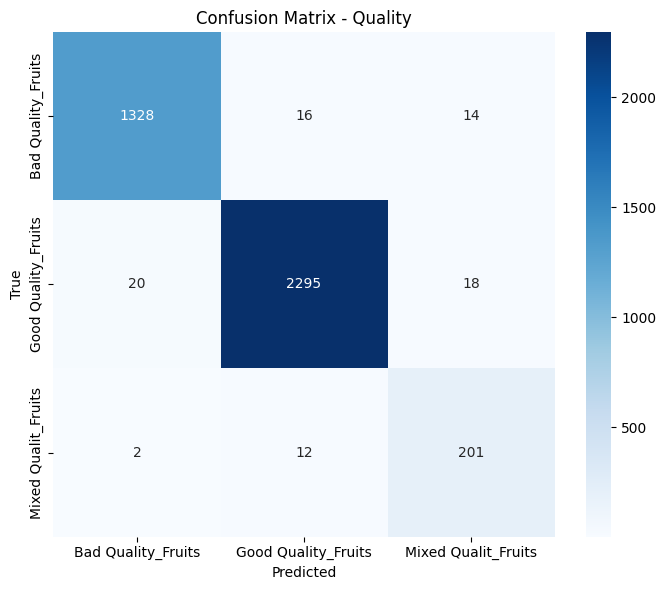

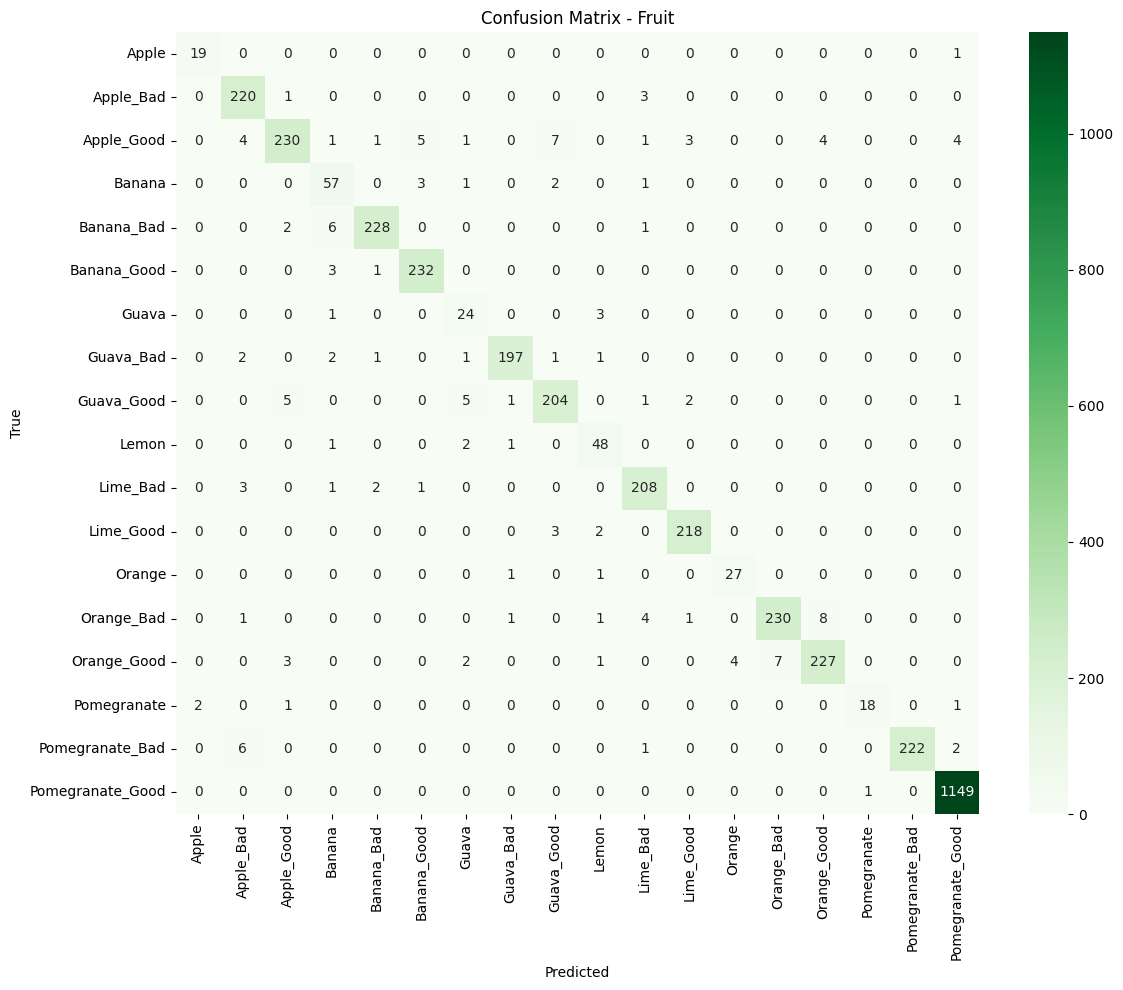

In [8]:
# =====================================================
# 1. Predict on Validation Set
# =====================================================

yq_pred_prob, yf_pred_prob = model.predict(
    X_val,
    verbose=1
)


# Convert probabilities to class indices
yq_pred = np.argmax(yq_pred_prob, axis=1)
yq_true = np.argmax(yq_val, axis=1)

yf_pred = np.argmax(yf_pred_prob, axis=1)
yf_true = np.argmax(yf_val, axis=1)


# =====================================================
# 2. Confusion Matrix - Quality
# =====================================================

cm_q = confusion_matrix(
    yq_true,
    yq_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_q,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_quality.classes_,
    yticklabels=le_quality.classes_
)

plt.title("Confusion Matrix - Quality")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


# =====================================================
# 3. Confusion Matrix - Fruit
# =====================================================

cm_f = confusion_matrix(
    yf_true,
    yf_pred
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_f,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=le_fruit.classes_,
    yticklabels=le_fruit.classes_
)

plt.title("Confusion Matrix - Fruit")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

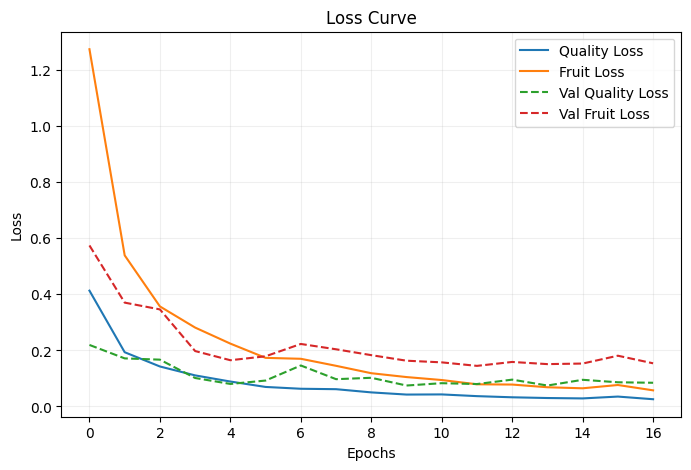

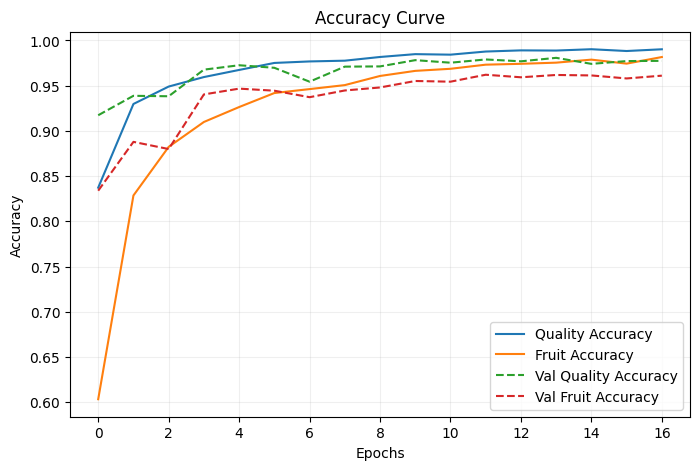

In [9]:
# =====================================================
# Loss & Accuracy Curves
# =====================================================

# -------------------------------
# Loss Curves
# -------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['quality_output_loss'],
    label='Quality Loss'
)

plt.plot(
    history.history['fruit_output_loss'],
    label='Fruit Loss'
)

plt.plot(
    history.history['val_quality_output_loss'],
    '--',
    label='Val Quality Loss'
)

plt.plot(
    history.history['val_fruit_output_loss'],
    '--',
    label='Val Fruit Loss'
)

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


# -------------------------------
# Accuracy Curves
# -------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['quality_output_accuracy'],
    label='Quality Accuracy'
)

plt.plot(
    history.history['fruit_output_accuracy'],
    label='Fruit Accuracy'
)

plt.plot(
    history.history['val_quality_output_accuracy'],
    '--',
    label='Val Quality Accuracy'
)

plt.plot(
    history.history['val_fruit_output_accuracy'],
    '--',
    label='Val Fruit Accuracy'
)

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [12]:
# =====================================================
# Create Test Set
# =====================================================

from sklearn.model_selection import train_test_split
import numpy as np


# Create indices for the full dataset
indices = np.arange(len(X))


# Split into Train+Validation and Test
train_val_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y_quality
)


# Split Train+Validation into Train and Validation
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.25,
    random_state=42,
    stratify=y_quality[train_val_idx]
)


# Create Test Set
X_test = X[test_idx]

yq_test = y_quality_onehot[test_idx]
yf_test = y_fruit_onehot[test_idx]


print("Test images:", X_test.shape)
print("Test quality labels:", yq_test.shape)
print("Test fruit labels:", yf_test.shape)

Test images: (3906, 128, 128, 3)
Test quality labels: (3906, 3)
Test fruit labels: (3906, 18)


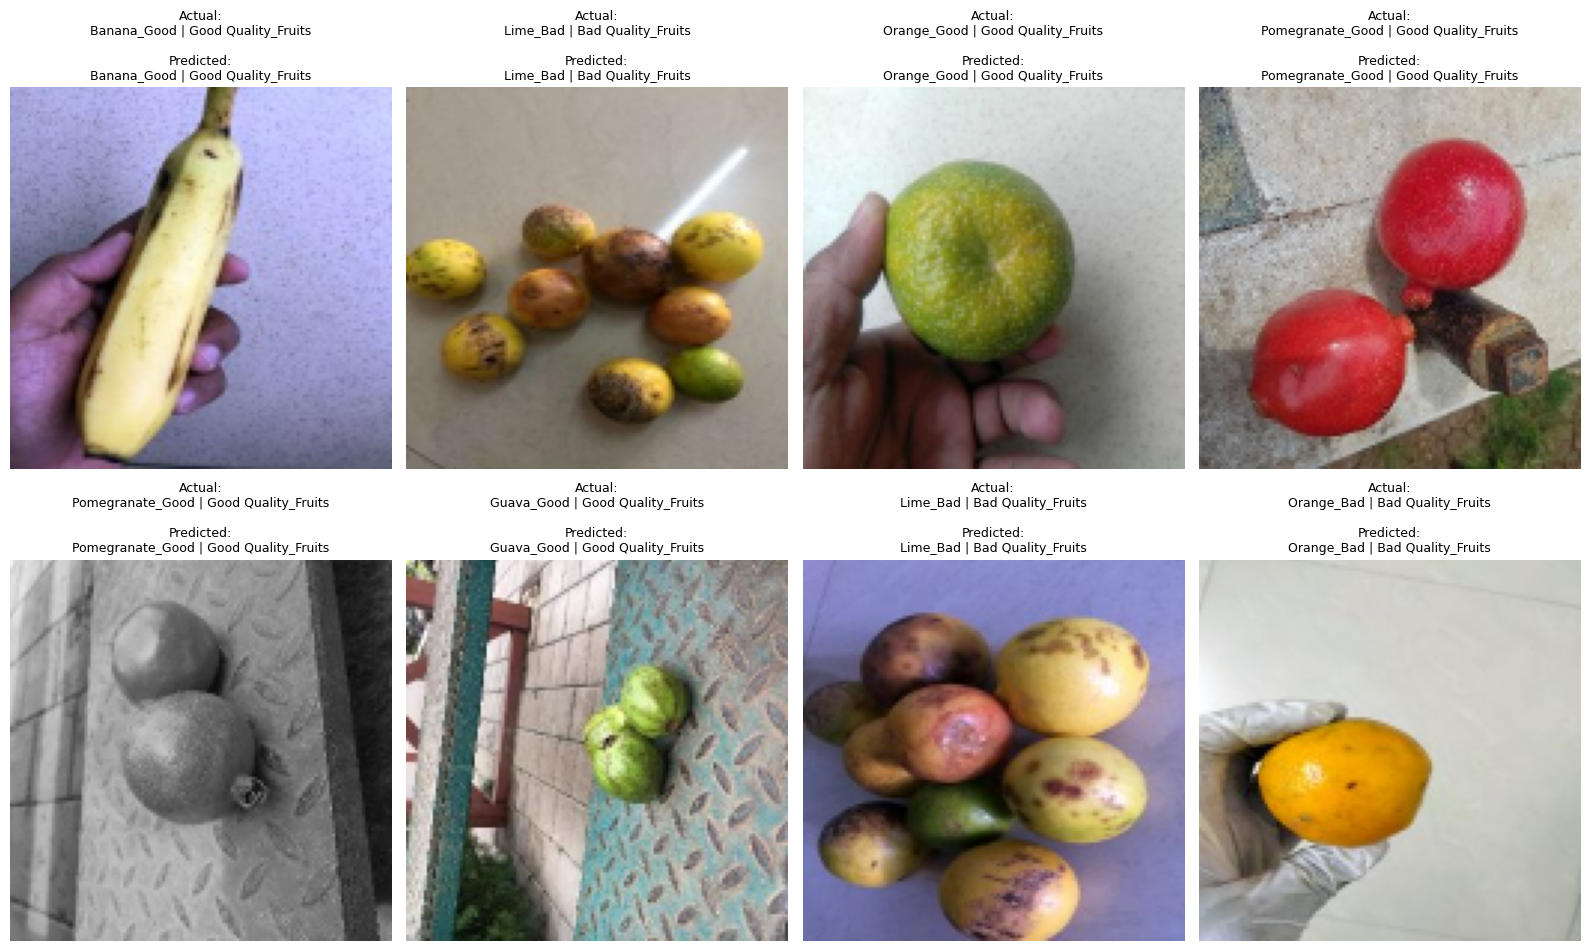

In [13]:
# =====================================================
# Select Test Images
# =====================================================

num_samples = min(8, len(X_test))

sample_indices = np.random.choice(
    len(X_test),
    size=num_samples,
    replace=False
)

X_sample = X_test[sample_indices]
yq_actual = np.argmax(yq_test[sample_indices], axis=1)
yf_actual = np.argmax(yf_test[sample_indices], axis=1)


# =====================================================
# Make Predictions
# =====================================================

y_pred_quality, y_pred_fruit = model.predict(
    X_sample,
    verbose=0
)

quality_pred_num = np.argmax(y_pred_quality, axis=1)
fruit_pred_num = np.argmax(y_pred_fruit, axis=1)


# =====================================================
# Display Results
# =====================================================

plt.figure(figsize=(16, 10))

for i in range(num_samples):

    plt.subplot(2, 4, i + 1)

    plt.imshow(X_sample[i])
    plt.axis("off")

    actual_quality = le_quality.classes_[yq_actual[i]]
    predicted_quality = le_quality.classes_[quality_pred_num[i]]

    actual_fruit = le_fruit.classes_[yf_actual[i]]
    predicted_fruit = le_fruit.classes_[fruit_pred_num[i]]

    plt.title(
        f"Actual:\n"
        f"{actual_fruit} | {actual_quality}\n\n"

        f"Predicted:\n"
        f"{predicted_fruit} | {predicted_quality}",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [14]:
# =====================================================
# Save Model
# =====================================================

from IPython.display import FileLink

model.save("fruit_quality_model.h5")

print("Model saved successfully!")

# Create download link
FileLink("fruit_quality_model.h5")

Model saved successfully!


/kaggle/working/fruit_quality_model.h5